# Peeking Inside a Neural Network

We usually treat a neural network as a black box:

$$
X \longrightarrow \text{neural network} \longrightarrow \hat{Y}
$$

We train it, look at the loss and predictions, and decide whether it learned the task.

But what is actually happening **inside** the network?

In this demo, we will take a simple neural network and look at the representation it learns in its hidden layer.

The key idea is that the hidden layer can **transform the input data into a new feature space**. The output layer can then use that representation to make the final prediction.

For a nonlinear classification problem, where the original data is not linearly separable, the network can learn a transformation that makes the classes much easier to separate in the hidden representation.

We will make this transformation visible.

Rather than only asking:

> **"Did the network learn to classify the data?"**

we will also ask:

> **"What does the data look like inside the network after the hidden layer?"**

---

### A note about terminology

Our model contains two trainable linear layers:

* `linear1`: input → hidden representation
* `linear2`: hidden representation → output

Therefore `linear1` is a **hidden layer** because its output is an internal representation rather than the model's final prediction.

The input itself is not normally counted as a layer when we describe the depth of a neural network. Therefore, this is a **one-hidden-layer neural network**, also commonly called a **shallow neural network**.

---

Let's look inside the network and see that transformation for ourselves.


In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

## 1. Generate our data

We will create a simple binary classification problem with one input feature.

The input consists of values from -20 to 19. The class is determined by whether the input falls inside the interval (-4, 4):

* class 1 if `-4 < x < 4`
* class 0 otherwise

This is a nonlinear classification problem: a single linear decision boundary cannot isolate the middle interval. We therefore need the hidden layer to transform the input into a representation that makes the classes easier to separate.



In [94]:
X = torch.arange(-20, 20, 1).view(-1, 1).type(torch.FloatTensor)

Y = torch.zeros(X.shape[0], 1)
Y[(X[:, 0] > -4) & (X[:, 0] < 4), 0] = 1.0

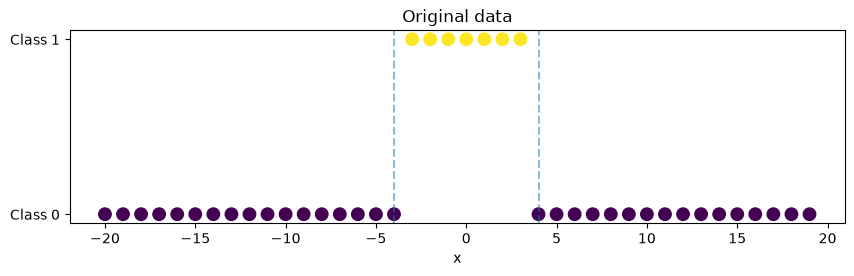

In [95]:
plt.figure(figsize=(10, 2.5))

labels = Y.squeeze()

plt.scatter(
    X.squeeze(),
    labels,
    c=labels,
    s=80
)

plt.axvline(-4, linestyle="--", alpha=0.5)
plt.axvline(4, linestyle="--", alpha=0.5)

plt.xlabel("x")
plt.yticks([0, 1], ["Class 0", "Class 1"])
plt.title("Original data")
plt.show()

## 2. Build the neural network

We'll use a small neural network with one hidden layer.

The two hidden neurons transform the original one-dimensional input into a two-dimensional representation. We will save that representation so that we can visualize it after training.

The important part for our experiment is:


$$
X
\longrightarrow
\underbrace{\sigma(W_1X+b_1)}_{\text{hidden representation}}
\longrightarrow
\sigma(W_2a_1+b_2) = \hat{Y}
$$


During the forward pass, we save the hidden representation so that we can later ask:

> **What happened to our data after passing through the hidden layer?**


In [96]:
class Net(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(Net, self).__init__()

        self.linear1 = nn.Linear(D_in, H)
        self.linear2 = nn.Linear(H, D_out)

        # We keep this so we can inspect the hidden representation later.
        # This is useful for this demonstration, but storing intermediate
        # activations as model attributes is generally not good design.
        self.hidden_representation = None

    def forward(self, x):
        self.hidden_representation = torch.sigmoid(self.linear1(x))
        l2 = self.linear2(self.hidden_representation)
        yhat = torch.sigmoid(l2)

        return yhat

## 3. Inspect the hidden representation

During training, we can look inside the network and see how the data is represented after the hidden layer.

Since we deliberately use two hidden neurons, every input is mapped to a point in a two-dimensional hidden space.

We color the points according to their class. If the network learns a useful representation, the two classes should become easier for the final linear layer to separate.

We also display the final predictions of the model vs the true lables coloured according to their class.



In [105]:
def plot_model_state(X, Y, model, epoch):
    probs = model(X).detach()
    hidden = model.hidden_representation.detach()

    labels = Y.squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(
        hidden[:, 0],
        hidden[:, 1],
        c=labels
    )
    axes[0].set_xlabel("hidden neuron 1")
    axes[0].set_ylabel("hidden neuron 2")
    axes[0].set_title("Hidden representation")

    axes[1].scatter(
        X.squeeze(),
        labels,
        s=60,
        c=labels
    )
    axes[1].plot(
        X.squeeze(),
        probs.squeeze(),
        label="Model probability"
    )
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("Probability")
    axes[1].set_title("Model predictions")
    axes[1].legend()

    fig.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 4. Train the network

Because the network already applies a sigmoid to its output, we use binary cross-entropy on the predicted probabilities and not nn.BCEWithLogitsLoss().


In [106]:
def train(Y, X, model, optimizer, criterion, epochs=1000):
    cost = []
    accuracy_history = []

    for epoch in range(epochs):
        total_loss = 0

        for y, x in zip(Y, X):
            yhat = model(x)

            loss = criterion(yhat, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        # Evaluate the whole dataset after the epoch
        with torch.no_grad():
            probs = model(X)
            predictions = (probs >= 0.5).float()
            accuracy = (predictions == Y).float().mean()

        cost.append(total_loss)
        accuracy_history.append(accuracy.item())

        if epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Loss: {total_loss:.4f} | "
                f"Accuracy: {accuracy.item():.2%}"
            )

            plot_model_state(X, Y, model, epoch)

    return cost, accuracy_history

Epoch    0 | Loss: 19.1504 | Accuracy: 82.50%


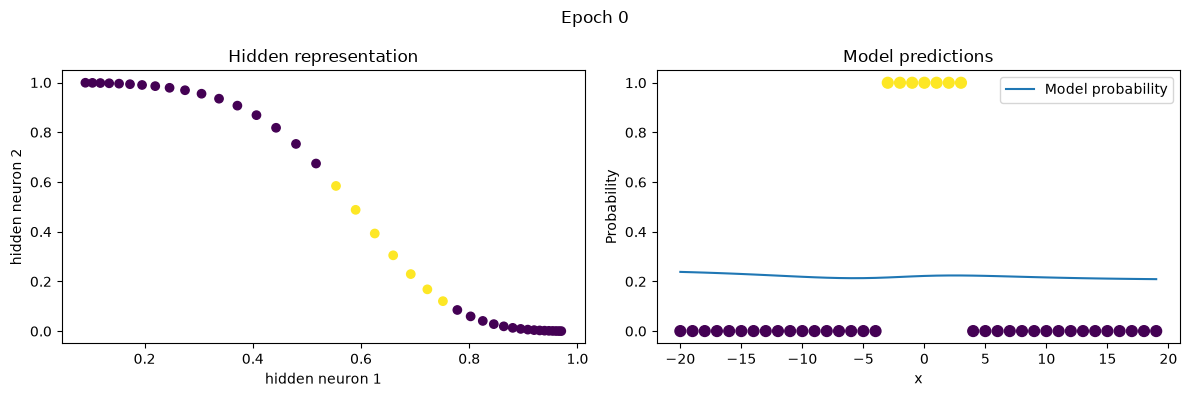

Epoch  100 | Loss: 3.4356 | Accuracy: 97.50%


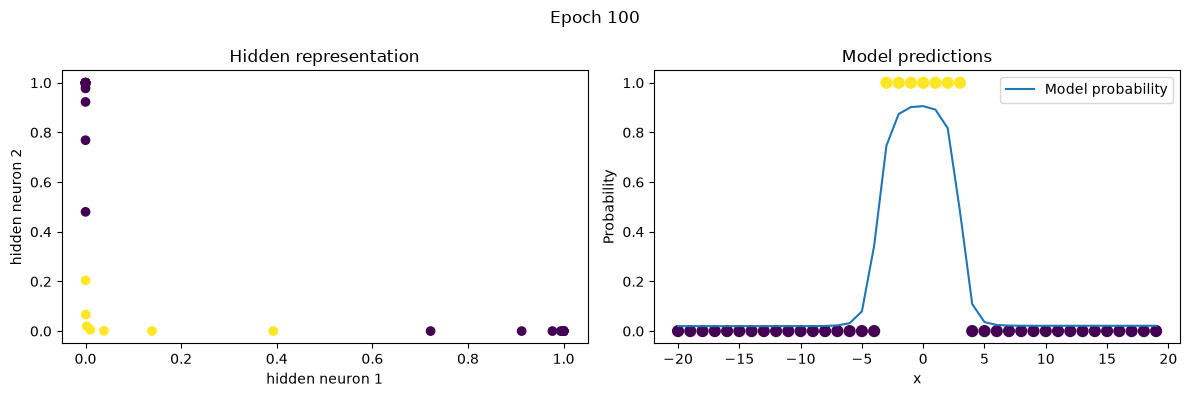

Epoch  200 | Loss: 1.4134 | Accuracy: 100.00%


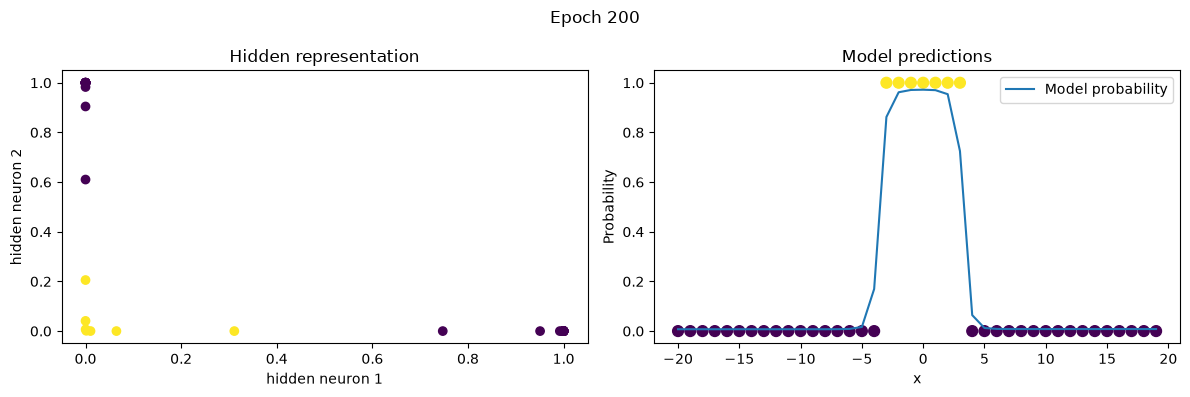

Epoch  300 | Loss: 0.7574 | Accuracy: 100.00%


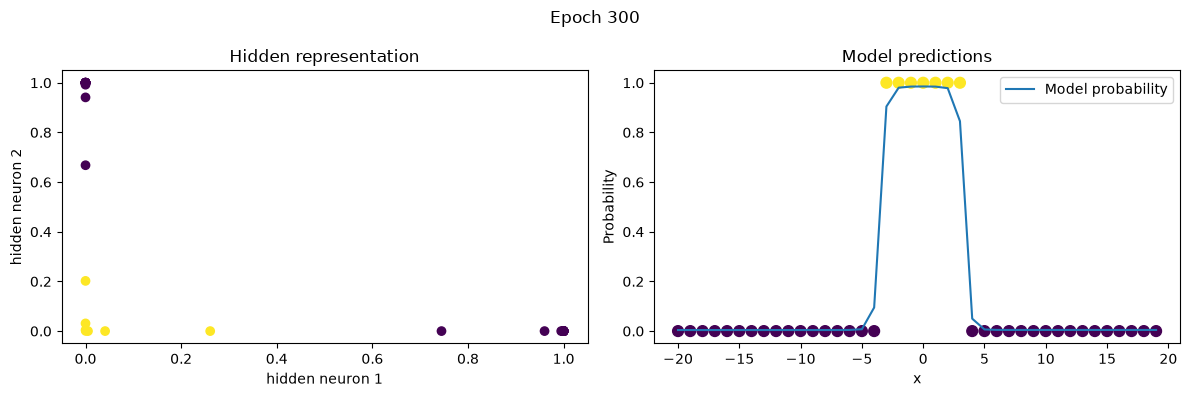

Epoch  400 | Loss: 0.4995 | Accuracy: 100.00%


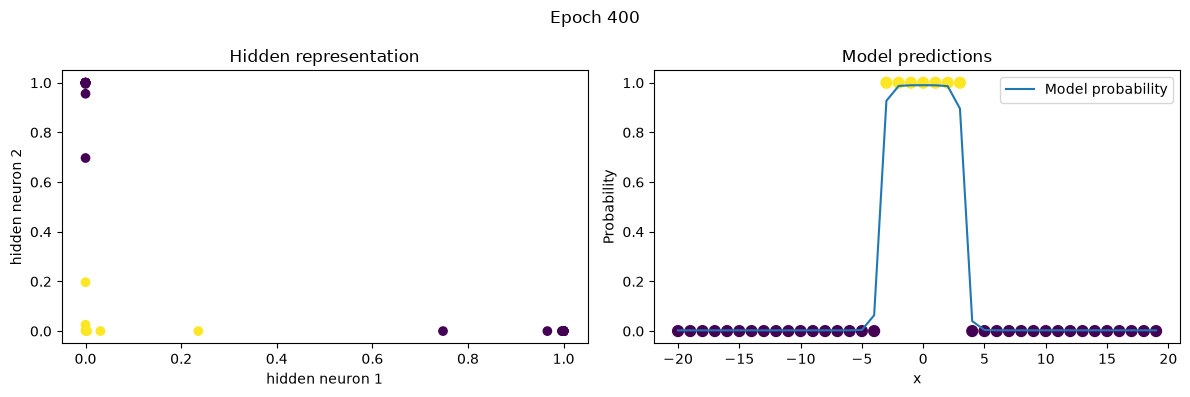

Epoch  500 | Loss: 0.3679 | Accuracy: 100.00%


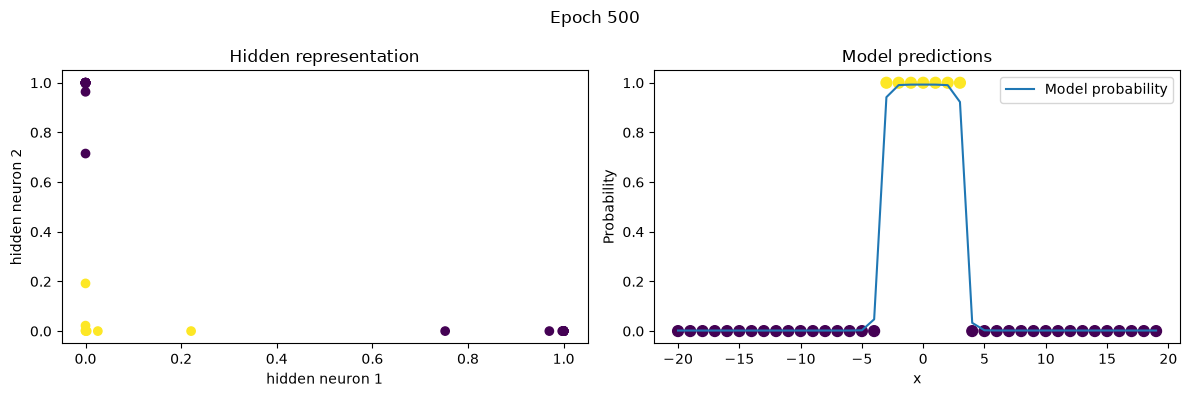

Epoch  600 | Loss: 0.2893 | Accuracy: 100.00%


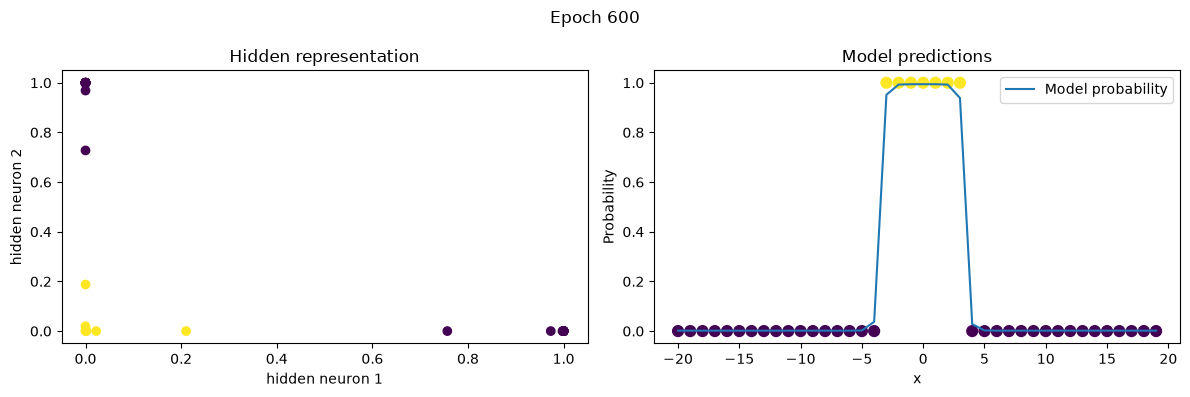

Epoch  700 | Loss: 0.2374 | Accuracy: 100.00%


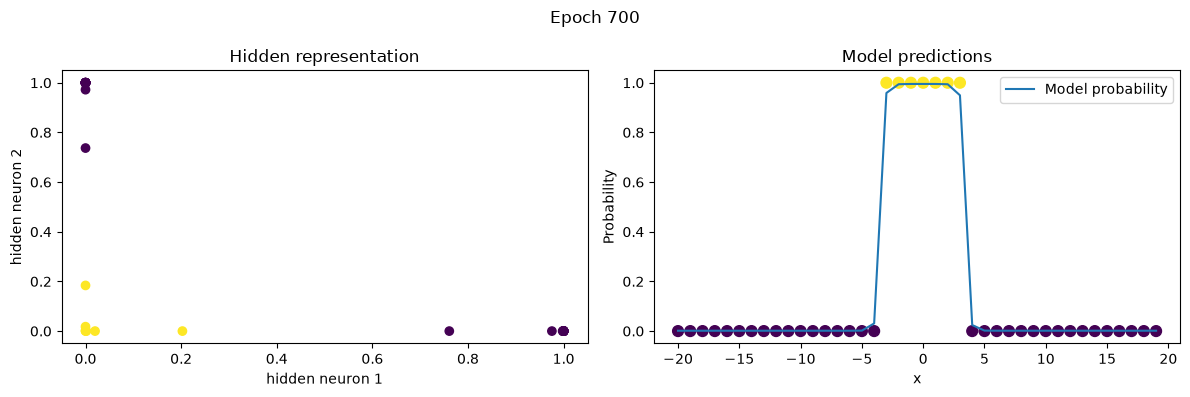

Epoch  800 | Loss: 0.2008 | Accuracy: 100.00%


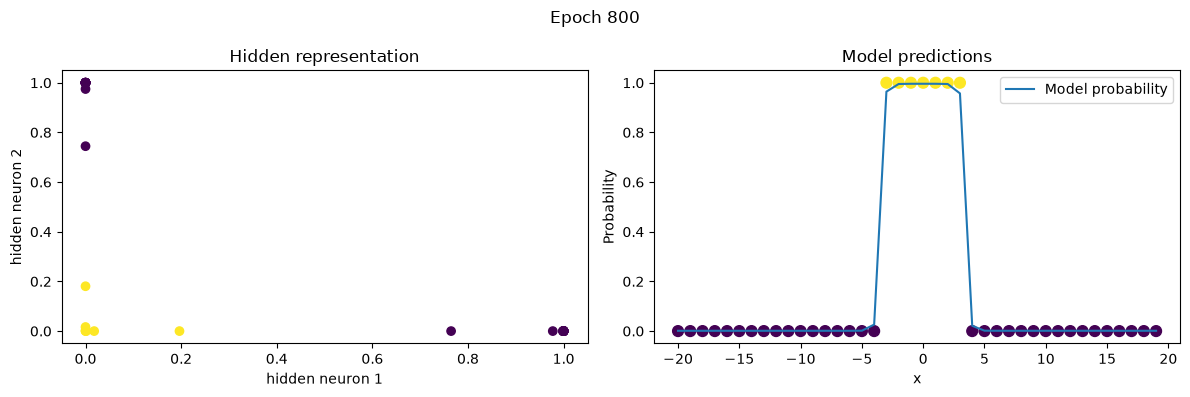

Epoch  900 | Loss: 0.1736 | Accuracy: 100.00%


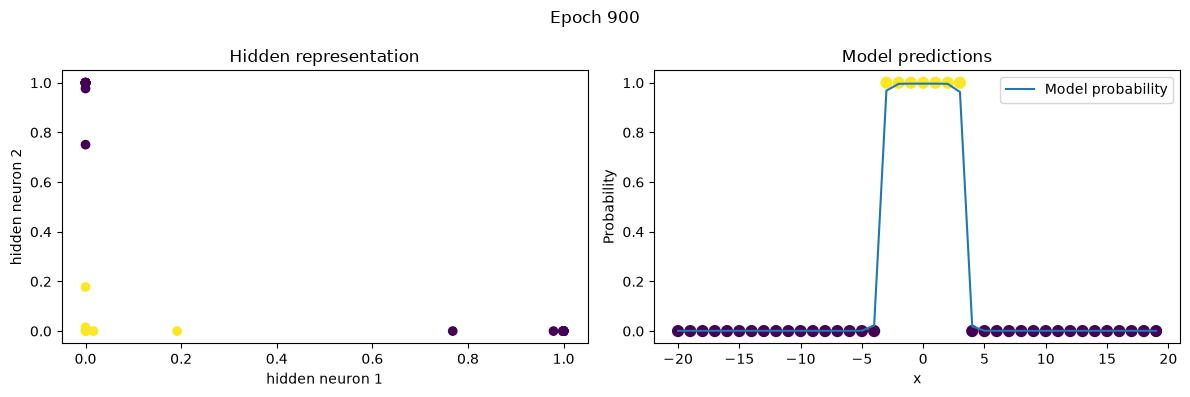

In [107]:
model = Net(D_in=1, H=2, D_out=1)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

criterion = nn.BCELoss()

cost, accuracy_history = train(Y, X, model, optimizer, criterion, epochs = 1000)

## 5. Finally, let's look at the training curves:

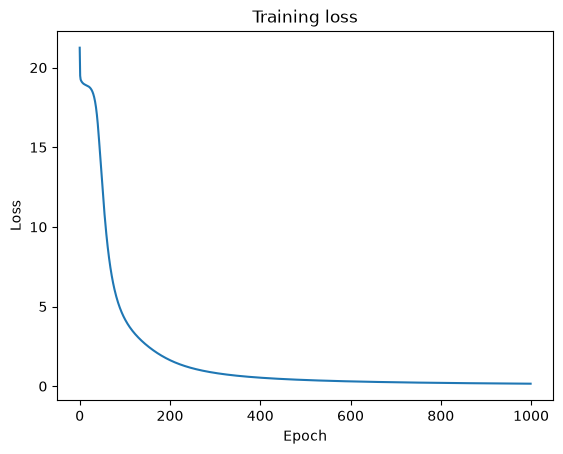

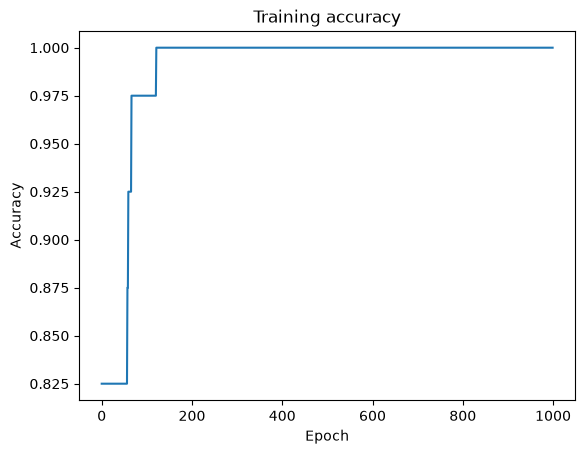

In [104]:
plt.plot(cost)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training accuracy")

plt.show()